# Reconciliador Backtest vs Live Signals

Compara las bets del backtest (`analyze_cartera` + filtros) contra las señales que `detect_betting_signals` habría generado fila a fila para cada partido histórico.

In [1]:
# ── Celda 1: Setup ──
import sys, os, json, builtins, warnings
from pathlib import Path
from unittest.mock import patch
from collections import defaultdict
from urllib.parse import unquote
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path(r'c:\Users\agonz\OneDrive\Documents\Proyectos\Furbo')
sys.path.insert(0, str(ROOT / 'betfair_scraper' / 'dashboard' / 'backend'))
sys.path.insert(0, str(ROOT / 'betfair_scraper'))

from utils import csv_reader
from api.optimize import (
    _filter_draw, _filter_xg, _filter_drift, _filter_clustering,
    _filter_pressure, _filter_tardesia, _filter_momentum,
    _filter_lay_over15, _filter_lay_draw_asym,
    _filter_back_sot_dom, _filter_back_over15_early,
    _filter_by_risk, _apply_realistic_adj,
)

# Load config
CONFIG_PATH = ROOT / 'betfair_scraper' / 'cartera_config.json'
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    CONFIG = json.load(f)

DATA_DIR = ROOT / 'betfair_scraper' / 'data'

# ── Derive combo from config ──
s = CONFIG.get('strategies', {})
md = CONFIG.get('min_duration', {})

def _ver_from_config(key, default):
    strat = s.get(key, {})
    if strat.get('enabled') is False:
        return 'off'
    return strat.get('version', default)

COMBO = {
    'draw': _ver_from_config('draw', 'v2r'),
    'xg': _ver_from_config('xg', 'base'),
    'drift': _ver_from_config('drift', 'v1'),
    'clustering': _ver_from_config('clustering', 'v2'),
    'pressure': _ver_from_config('pressure', 'v1'),
    'tardeAsia': 'v1' if s.get('tarde_asia', {}).get('enabled') else 'off',
    'momentumXG': s.get('momentum_xg', {}).get('version', 'v1'),
    'layOver15': _ver_from_config('lay_over15', 'off'),
    'layDrawAsym': 'on' if s.get('lay_draw_asym', {}).get('enabled') else 'off',
    'layOver25Def': 'on' if s.get('lay_over25_def', {}).get('enabled') else 'off',
    'backSotDom': 'on' if s.get('back_sot_dom', {}).get('enabled') else 'off',
    'backOver15Early': 'on' if s.get('back_over15_early', {}).get('enabled') else 'off',
    'layFalseFav': 'on' if s.get('lay_false_fav', {}).get('enabled') else 'off',
}

# Realistic adjustments in optimize.py format
adj_cfg = CONFIG.get('adjustments', {})
ADJ = {
    'globalMinuteMin': adj_cfg.get('global_minute_min'),
    'globalMinuteMax': adj_cfg.get('global_minute_max'),
    'driftMinMinute': adj_cfg.get('drift_min_minute'),
    'maxOdds': adj_cfg.get('max_odds'),
    'minOdds': adj_cfg.get('min_odds'),
    'dedup': adj_cfg.get('dedup', True),
    'conflictFilter': adj_cfg.get('conflict_filter', False),
    'allowContrarias': adj_cfg.get('allow_contrarias', True),
    'minStability': adj_cfg.get('stability', 1),
    'slippagePct': adj_cfg.get('slippage_pct', 0),
}
RISK_FILTER = CONFIG.get('risk_filter', 'all')

print(f'Config loaded. Combo: {COMBO}')
print(f'Adjustments: {ADJ}')
print(f'Risk filter: {RISK_FILTER}')

Config loaded. Combo: {'draw': 'v2r', 'xg': 'base', 'drift': 'v1', 'clustering': 'v2', 'pressure': 'v1', 'tardeAsia': 'v1', 'momentumXG': 'v1', 'layOver15': 'off', 'layDrawAsym': 'off', 'layOver25Def': 'off', 'backSotDom': 'off', 'backOver15Early': 'off', 'layFalseFav': 'off'}
Adjustments: {'globalMinuteMin': None, 'globalMinuteMax': None, 'driftMinMinute': 30, 'maxOdds': 7, 'minOdds': 1.21, 'dedup': True, 'conflictFilter': False, 'allowContrarias': False, 'minStability': 3, 'slippagePct': 3.5}
Risk filter: no_risk


In [2]:
# ── Celda 2: Backtest — obtener bets con config params ──
import importlib
import sys
from pathlib import Path as _P2

# AGGRESSIVE reload: remove module from sys.modules, then reimport
for mod_name in list(sys.modules.keys()):
    if 'csv_reader' in mod_name or 'optimize' in mod_name:
        del sys.modules[mod_name]

# Re-import fresh
from utils import csv_reader
from api import optimize as _opt_mod
from api.optimize import (
    _filter_draw, _filter_xg, _filter_drift, _filter_clustering,
    _filter_pressure, _filter_tardesia, _filter_momentum,
    _filter_lay_over15, _filter_lay_draw_asym,
    _filter_back_sot_dom, _filter_back_over15_early,
    _filter_by_risk, _apply_realistic_adj,
)

# Clear ALL caches (in-memory + disk)
for attr in dir(csv_reader):
    if 'cache' in attr.lower():
        obj = getattr(csv_reader, attr, None)
        if isinstance(obj, dict):
            obj.clear()

# Delete disk cache
disk_cache = _P2(ROOT / 'betfair_scraper' / 'data' / '.cartera_cache.json')
if disk_cache.exists():
    disk_cache.unlink()
    print(f'  Deleted disk cache: {disk_cache.name}')

# 1. Get superset from analyze_cartera
bt_raw = csv_reader.analyze_cartera()
all_bets = bt_raw.get('bets', [])
print(f'Superconjunto (analyze_cartera): {len(all_bets)} bets')

# Count by strategy
from collections import Counter
strat_counts = Counter(b.get('strategy', '') for b in all_bets)
for k, v in sorted(strat_counts.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v}')

# 2. Apply version filters (optimize.py) for versioned strategies
FILTER_MAP = {
    'draw': ('draw', _filter_draw),
    'xg': ('xg', _filter_xg),
    'drift': ('drift', _filter_drift),
    'clustering': ('clustering', _filter_clustering),
    'pressure': ('pressure', _filter_pressure),
    'tardeAsia': ('tardeAsia', _filter_tardesia),
    'momentumXG': ('momentumXG', _filter_momentum),
    'layOver15': ('layOver15', _filter_lay_over15),
    'layDrawAsym': ('layDrawAsym', _filter_lay_draw_asym),
    'backSotDom': ('backSotDom', _filter_back_sot_dom),
    'backOver15Early': ('backOver15Early', _filter_back_over15_early),
}

bt_filtered = []
for combo_key, (_, filter_fn) in FILTER_MAP.items():
    ver = COMBO.get(combo_key, 'off')
    filtered = filter_fn(all_bets, ver)
    bt_filtered.extend(filtered)
    if filtered:
        print(f'  {combo_key} ({ver}): {len(filtered)} bets')

# 3. On/off strategies from superset with config filters
lo25_cfg = s.get('lay_over25_def', {})
lff_cfg = s.get('lay_false_fav', {})

if COMBO.get('layOver25Def') != 'off':
    lo25_bets = [b for b in all_bets if b.get('strategy') == 'lay_over25_def']
    goals_max_cfg = lo25_cfg.get('goalsMax', 1)
    xg_max_cfg = lo25_cfg.get('xgMax', 2.0)
    lo25_filtered = [b for b in lo25_bets
                     if b.get('total_goals_trigger', 0) <= goals_max_cfg
                     and (b.get('xg_total') is None or b.get('xg_total') < xg_max_cfg)]
    bt_filtered.extend(lo25_filtered)
    print(f'  layOver25Def (on, goals<={goals_max_cfg}, xg<{xg_max_cfg}): {len(lo25_filtered)} bets')

if COMBO.get('layFalseFav') != 'off':
    lff_bets = [b for b in all_bets if b.get('strategy') == 'lay_false_fav']
    xg_ratio_min = lff_cfg.get('xgRatioMin', 2.0)
    fav_odds_max = lff_cfg.get('favOddsMax', 1.70)
    lff_filtered = [b for b in lff_bets
                    if not (b.get('xg_ratio') is not None and b['xg_ratio'] < xg_ratio_min)
                    and not (b.get('fav_back_odds') is not None and b['fav_back_odds'] > fav_odds_max)]
    bt_filtered.extend(lff_filtered)
    print(f'  layFalseFav (on, xgRatio>={xg_ratio_min}, favOdds<={fav_odds_max}): {len(lff_filtered)} bets')

# 4. FRONTEND POST-FILTERS
def _fv(b, k):
    v = b.get(k)
    if v is None: return None
    try: return float(v)
    except (ValueError, TypeError): return None

n_before = len(bt_filtered)

# 4a. Clustering minuteMax
cl_cfg = s.get('clustering', {})
cl_minute_max = cl_cfg.get('minuteMax', 90)
cl_minute_min = cl_cfg.get('minuteMin', 0)
if cl_minute_max < 90 or cl_minute_min > 0:
    filtered_new = []
    cl_removed = 0
    for b in bt_filtered:
        if b.get('strategy') == 'goal_clustering':
            mn = _fv(b, 'minuto')
            if mn is not None:
                if cl_minute_min > 0 and mn < cl_minute_min:
                    cl_removed += 1; continue
                if cl_minute_max < 90 and mn >= cl_minute_max:
                    cl_removed += 1; continue
        filtered_new.append(b)
    bt_filtered = filtered_new
    print(f'  Clustering config filter (min>={cl_minute_min}, max<{cl_minute_max}): removed {cl_removed}')

# 4b. Drift oddsMax and momGapMin
dr_cfg = s.get('drift', {})
dr_odds_max = dr_cfg.get('oddsMax', 999)
dr_mom_gap_min = dr_cfg.get('momGapMin', 0)
if dr_odds_max < 999 or dr_mom_gap_min > 0:
    filtered_new = []
    dr_removed = 0
    for b in bt_filtered:
        if b.get('strategy') == 'odds_drift':
            if dr_odds_max < 999:
                odds = _fv(b, 'back_odds')
                if odds is not None and odds > dr_odds_max:
                    dr_removed += 1; continue
            if dr_mom_gap_min > 0:
                mgap = _fv(b, 'synth_momentum_gap')
                if mgap is not None and mgap <= dr_mom_gap_min:
                    dr_removed += 1; continue
        filtered_new.append(b)
    bt_filtered = filtered_new
    print(f'  Drift config filter (oddsMax={dr_odds_max}, momGap>{dr_mom_gap_min}): removed {dr_removed}')

# 4c. Momentum minuteMin/Max with live sentinel logic
mom_cfg_s = s.get('momentum_xg', {})
mom_minute_min = mom_cfg_s.get('minuteMin', 0)
mom_minute_max = mom_cfg_s.get('minuteMax', 90)
mom_eff_min = mom_minute_min if mom_minute_min > 0 else 10
mom_eff_max = mom_minute_max if mom_minute_max < 90 else 80
if mom_eff_min > 0 or mom_eff_max < 90:
    filtered_new = []
    mom_removed = 0
    for b in bt_filtered:
        if b.get('strategy') in ('momentum_xg_v1', 'momentum_xg_v2'):
            mn = _fv(b, 'minuto')
            if mn is not None and (mn < mom_eff_min or mn > mom_eff_max):
                mom_removed += 1; continue
        filtered_new.append(b)
    bt_filtered = filtered_new
    print(f'  Momentum config filter (min>={mom_eff_min}, max<={mom_eff_max}): removed {mom_removed}')

print(f'  Frontend post-filters: {n_before} -> {len(bt_filtered)} ({n_before - len(bt_filtered)} removed)')

bt_filtered.sort(key=lambda b: b.get('timestamp_utc') or '')

# ── Normalize BT strategy names ──
STRATEGY_TO_FAMILY = {
    'back_draw_00': 'back_draw_00', 'xg_underperformance': 'xg_underperformance',
    'odds_drift': 'odds_drift', 'goal_clustering': 'goal_clustering',
    'pressure_cooker': 'pressure_cooker', 'momentum_xg_v1': 'momentum_xg',
    'momentum_xg_v2': 'momentum_xg', 'tarde_asia': 'tarde_asia',
    'lay_over15': 'lay_over15', 'lay_draw_asym': 'lay_draw_asym',
    'lay_over25_def': 'lay_over25_def', 'back_sot_dom': 'back_sot_dom',
    'back_over15_early': 'back_over15_early', 'lay_false_fav': 'lay_false_fav',
}

def _get_bt_odds(b):
    for k in ['back_draw', 'back_odds', 'over_odds', 'back_over_odds',
              'lay_over15_odds', 'lay_draw_odds', 'lay_over25_odds',
              'back_sot_odds', 'back_over15_odds', 'lay_false_fav_odds']:
        v = b.get(k)
        if v is not None and v > 1.0:
            return v
    return None

def _bt_to_records(bets):
    records = []
    for b in bets:
        strat = b.get('strategy', '')
        family = STRATEGY_TO_FAMILY.get(strat, strat)
        records.append({
            'match_id': b.get('match_id', ''),
            'strategy_family': family,
            'minuto_bt': b.get('minuto'),
            'odds_bt': _get_bt_odds(b),
            'won_bt': b.get('won'),
            'pl_bt': b.get('pl'),
        })
    return pd.DataFrame(records)

def _dedup_clustering(df):
    clust = df[df['strategy_family'] == 'goal_clustering'].copy()
    other = df[df['strategy_family'] != 'goal_clustering']
    if len(clust) == 0: return df
    clust = clust.sort_values('minuto_bt')
    clust = clust.drop_duplicates(subset='match_id', keep='first')
    return pd.concat([other, clust], ignore_index=True)

df_bt_raw = _bt_to_records(bt_filtered)
n_before = len(df_bt_raw[df_bt_raw['strategy_family'] == 'goal_clustering'])
df_bt_raw = _dedup_clustering(df_bt_raw)
n_after = len(df_bt_raw[df_bt_raw['strategy_family'] == 'goal_clustering'])
print(f'\nClustering dedup: {n_before} -> {n_after}')
print(f'BT pre-adj: {len(df_bt_raw)} bets across {df_bt_raw["match_id"].nunique()} matches')
print(df_bt_raw.groupby('strategy_family').size().sort_values(ascending=False))

bt_risk = bt_filtered
if RISK_FILTER and RISK_FILTER != 'all':
    bt_risk = _filter_by_risk(bt_risk, RISK_FILTER)
bt_final = _apply_realistic_adj(bt_risk, ADJ)
df_bt = _bt_to_records(bt_final)
df_bt = _dedup_clustering(df_bt)
print(f'\nBT post-adj: {len(df_bt)} bets across {df_bt["match_id"].nunique()} matches')

Superconjunto (analyze_cartera): 1515 bets
  back_draw_00: 411
  goal_clustering: 285
  momentum_xg_v2: 215
  momentum_xg_v1: 186
  xg_underperformance: 127
  pressure_cooker: 117
  tarde_asia: 100
  odds_drift: 74
  draw (v2r): 261 bets
  xg (base): 84 bets
  drift (v1): 73 bets
  clustering (v2): 285 bets
  pressure (v1): 117 bets
  tardeAsia (v1): 100 bets
  momentumXG (v1): 186 bets
  Clustering config filter (min>=0, max<60): removed 88
  Momentum config filter (min>=10, max<=80): removed 33
  Frontend post-filters: 1106 -> 985 (121 removed)

Clustering dedup: 197 -> 197
BT pre-adj: 985 bets across 641 matches
strategy_family
back_draw_00           261
goal_clustering        197
momentum_xg            153
pressure_cooker        117
tarde_asia             100
xg_underperformance     84
odds_drift              73
dtype: int64

BT post-adj: 670 bets across 535 matches


In [3]:
# ── Celda 3: Live sim helper functions ──
import csv
import glob as glob_mod
import time as _time
from pathlib import Path as _Path
from urllib.parse import unquote as _unquote

# ── PERFORMANCE FIX: stub out signals_log.csv reading ──
# detect_betting_signals reads signals_log.csv on EVERY call (line 3344-3360).
# For 890 matches × ~100 rows = ~89k reads. We patch Path.exists to return False
# for that file, eliminating I/O overhead.
_original_path_exists = _Path.exists
_signals_log_name = 'signals_log.csv'

def _patched_path_exists(self):
    if self.name == _signals_log_name:
        return False
    return _original_path_exists(self)

_Path.exists = _patched_path_exists

# Also: core strategies only (BT only has 7, lay strategies have no BT equivalent)
CORE_FAMILIES = {
    'back_draw_00', 'xg_underperformance', 'odds_drift',
    'goal_clustering', 'pressure_cooker', 'momentum_xg', 'tarde_asia',
    'lay_over15', 'lay_draw_asym', 'lay_over25_def',
    'back_sot_dom', 'back_over15_early', 'lay_false_fav',
}

def _build_versions_full(config):
    """Build versions dict — mirrors analytics.py completely (13 strategies)."""
    s = config.get('strategies', {})
    md = config.get('min_duration', {})
    draw_s = s.get('draw', {})
    xg_s = s.get('xg', {})
    drift_s = s.get('drift', {})
    cl_s = s.get('clustering', {})
    pr_s = s.get('pressure', {})
    mom_s = s.get('momentum_xg', {})
    ta_s = s.get('tarde_asia', {})
    lo15_s = s.get('lay_over15', {})
    lda_s = s.get('lay_draw_asym', {})
    lo25_s = s.get('lay_over25_def', {})
    bsd_s = s.get('back_sot_dom', {})
    bo15_s = s.get('back_over15_early', {})
    lff_s = s.get('lay_false_fav', {})

    def _ver(s_key, default):
        strat = s.get(s_key, {})
        if strat.get('enabled') is False:
            return 'off'
        if strat.get('version'):
            return strat['version']
        return default

    momentum_ver = mom_s.get('version') or 'off'
    tarde_asia_ver = 'v1' if ta_s.get('enabled') else 'off'

    return {
        'draw': _ver('draw', 'v2r'),
        'xg': _ver('xg', 'base'),
        'drift': _ver('drift', 'v1'),
        'clustering': _ver('clustering', 'v2'),
        'pressure': _ver('pressure', 'v1'),
        'momentum': momentum_ver,
        'tarde_asia': tarde_asia_ver,
        'lay_over15': _ver('lay_over15', 'off'),
        'draw_min_dur': str(md.get('draw', 1)),
        'xg_min_dur': str(md.get('xg', 2)),
        'drift_min_dur': str(md.get('drift', 2)),
        'clustering_min_dur': str(md.get('clustering', 4)),
        'pressure_min_dur': str(md.get('pressure', 2)),
        'lay_over15_min_dur': str(md.get('lay_over15', 2)),
        'drift_threshold': str(drift_s.get('driftMin', 30)),
        'drift_odds_max': str(drift_s.get('oddsMax', 999)),
        'drift_goal_diff_min': str(drift_s.get('goalDiffMin', 0)),
        'drift_minute_min': str(drift_s.get('minuteMin', 0)),
        'drift_minute_max': str(drift_s.get('minuteMax', 90)),
        'drift_mom_gap_min': str(drift_s.get('momGapMin', 0)),
        'clustering_minute_max': str(cl_s.get('minuteMax', 90)),
        'clustering_xg_rem_min': str(cl_s.get('xgRemMin', 0.6)),
        'clustering_sot_min': str(cl_s.get('sotMin', 2)),
        'clustering_minute_min': str(cl_s.get('minuteMin', 0)),
        'xg_minute_max': str(xg_s.get('minuteMax', 90)),
        'xg_sot_min': str(xg_s.get('sotMin', 0)),
        'xg_xg_excess_min': str(xg_s.get('xgExcessMin', 0.3)),
        'xg_minute_min': str(xg_s.get('minuteMin', 0)),
        'draw_xg_max': str(draw_s.get('xgMax', 1.0)),
        'draw_poss_max': str(draw_s.get('possMax', 100)),
        'draw_shots_max': str(draw_s.get('shotsMax', 20)),
        'draw_minute_min': str(draw_s.get('minuteMin', 30)),
        'draw_minute_max': str(draw_s.get('minuteMax', 90)),
        'draw_xg_dom_asym': str(draw_s.get('xgDomAsym', False)).lower(),
        'pressure_minute_min': str(pr_s.get('minuteMin', 0)),
        'pressure_minute_max': str(pr_s.get('minuteMax', 90)),
        'momentum_minute_min': str(mom_s.get('minuteMin', 0)),
        'momentum_minute_max': str(mom_s.get('minuteMax', 90)),
        'lay_over15_minute_min': str(lo15_s.get('minuteMin', 75)),
        'lay_over15_minute_max': str(lo15_s.get('minuteMax', 85)),
        'lay_over15_xg_min': str(lo15_s.get('xgMin', 0.5)),
        'lay_over15_poss_max': str(lo15_s.get('possMax', 30)),
        'lay_over15_shots_min': str(lo15_s.get('shotsMin', 12)),
        'lay_draw_asym': 'on' if lda_s.get('enabled', False) else 'off',
        'lay_draw_asym_minute_min': str(lda_s.get('minuteMin', 65)),
        'lay_draw_asym_minute_max': str(lda_s.get('minuteMax', 75)),
        'lay_draw_asym_xg_ratio_min': str(lda_s.get('xgRatioMin', 2.5)),
        'lay_draw_asym_xg_dom_min': str(lda_s.get('xgDomMin', 0.5)),
        'lay_draw_asym_min_dur': str(md.get('lay_draw_asym', 2)),
        'lay_over25_def': 'on' if lo25_s.get('enabled', True) else 'off',
        'lay_over25_def_minute_min': str(lo25_s.get('minuteMin', 65)),
        'lay_over25_def_minute_max': str(lo25_s.get('minuteMax', 80)),
        'lay_over25_def_xg_max': str(lo25_s.get('xgMax', 2.0)),
        'lay_over25_def_goals_max': str(lo25_s.get('goalsMax', 1)),
        'lay_over25_def_min_dur': str(md.get('lay_over25_def', 2)),
        'back_sot_dom': 'on' if bsd_s.get('enabled', False) else 'off',
        'back_sot_dom_minute_min': str(bsd_s.get('minuteMin', 60)),
        'back_sot_dom_minute_max': str(bsd_s.get('minuteMax', 80)),
        'back_sot_dom_sot_min': str(bsd_s.get('sotMin', 4)),
        'back_sot_dom_sot_max_rival': str(bsd_s.get('sotMaxRival', 1)),
        'back_sot_dom_min_dur': str(md.get('back_sot_dom', 1)),
        'back_over15_early': 'on' if bo15_s.get('enabled', False) else 'off',
        'back_over15_early_minute_min': str(bo15_s.get('minuteMin', 25)),
        'back_over15_early_minute_max': str(bo15_s.get('minuteMax', 45)),
        'back_over15_early_xg_min': str(bo15_s.get('xgMin', 1.0)),
        'back_over15_early_sot_min': str(bo15_s.get('sotMin', 4)),
        'back_over15_early_goals_max': str(bo15_s.get('goalsMax', 1)),
        'back_over15_early_min_dur': str(md.get('back_over15_early', 1)),
        'lay_false_fav': 'on' if lff_s.get('enabled', False) else 'off',
        'lay_false_fav_minute_min': str(lff_s.get('minuteMin', 65)),
        'lay_false_fav_minute_max': str(lff_s.get('minuteMax', 85)),
        'lay_false_fav_xg_ratio_min': str(lff_s.get('xgRatioMin', 2.0)),
        'lay_false_fav_fav_odds_max': str(lff_s.get('favOddsMax', 1.70)),
        'lay_false_fav_min_dur': str(md.get('lay_false_fav', 1)),
    }


# ── Normalization: live signal key -> backtest family ──
LIVE_TO_BT_FAMILY = {
    'odds_drift_contrarian': 'odds_drift',
}

def _normalize_strategy(key):
    """Normalize live signal strategy key to backtest family name."""
    base = key
    for suffix in ['_v1', '_v15', '_v2', '_v2r', '_v3', '_v4', '_v5', '_v6', '_base']:
        if base.endswith(suffix):
            base = base[:-len(suffix)]
            break
    return LIVE_TO_BT_FAMILY.get(base, base)


def _get_signal_odds(sig):
    """Extract odds from a live signal dict."""
    return sig.get('back_odds') or sig.get('lay_odds')


def _read_csv_rows_raw(csv_path):
    """Read all rows from a partido CSV."""
    with open(csv_path, 'r', encoding='utf-8') as f:
        return list(csv.DictReader(f))


def _extract_match_id(csv_path):
    """Extract match_id from filename, URL-decoded to match analyze_cartera()."""
    name = _Path(csv_path).stem
    if name.startswith('partido_'):
        raw = name[len('partido_'):]
    else:
        raw = name
    return _unquote(raw)


def _simulate_match(csv_path, versions, min_dur_map):
    """
    Simulate detect_betting_signals row-by-row for a single match.
    
    Maturity logic aligned with BT: signal fires when it first appears AND is
    still present min_dur rows later (BT's "trigger at idx, entry at idx+min_dur-1").
    """
    all_rows = _read_csv_rows_raw(csv_path)
    if len(all_rows) < 3:
        return []

    match_id = _extract_match_id(csv_path)
    csv_path_obj = _Path(csv_path)

    first_seen = {}       # family -> row index of first appearance
    first_seen_data = {}  # family -> {minute, odds} at first appearance
    fired = {}            # family -> data (only fires once per family)
    
    _original_load_games = csv_reader.load_games
    _original_resolve = csv_reader._resolve_csv_path
    _original_read_rows = csv_reader._read_csv_rows
    _original_open = builtins.open

    try:
        game_entry = [{'match_id': match_id, 'name': match_id, 'status': 'live', 'url': ''}]
        csv_reader.load_games = lambda _ge=game_entry: _ge
        csv_reader._resolve_csv_path = lambda mid, _p=csv_path_obj: _p

        def _patched_open(file, *a, **kw):
            if 'placed_bets' in str(file):
                raise FileNotFoundError('patched')
            return _original_open(file, *a, **kw)
        builtins.open = _patched_open

        signals_by_row = []
        
        for i in range(len(all_rows)):
            partial_rows = all_rows[:i + 1]
            csv_reader._read_csv_rows = lambda path, _pr=partial_rows: _pr

            try:
                result = csv_reader.detect_betting_signals(versions)
                signals = result.get('signals', [])
            except Exception:
                signals = []

            row_signals = {}
            for sig in signals:
                key = sig.get('strategy', '')
                family = _normalize_strategy(key)
                if family not in row_signals:
                    row_signals[family] = {
                        'minute': sig.get('minute'),
                        'odds': _get_signal_odds(sig),
                        'strategy_key': key,
                    }
            signals_by_row.append(row_signals)

        # Process maturity: find first appearance, check at first_seen + min_dur
        for i, row_sigs in enumerate(signals_by_row):
            for family, data in row_sigs.items():
                if family in fired:
                    continue
                if family not in first_seen:
                    first_seen[family] = i
                    first_seen_data[family] = data
            
            for family in list(first_seen.keys()):
                if family in fired:
                    continue
                start_i = first_seen[family]
                min_dur = min_dur_map.get(family, 1)
                target_i = start_i + min_dur - 1
                
                if i == target_i:
                    if family in signals_by_row[i]:
                        fired[family] = first_seen_data[family]
                    else:
                        del first_seen[family]
                        del first_seen_data[family]
                elif i > target_i and family not in fired:
                    if family not in row_sigs:
                        del first_seen[family]
                        del first_seen_data[family]

    finally:
        csv_reader.load_games = _original_load_games
        csv_reader._resolve_csv_path = _original_resolve
        csv_reader._read_csv_rows = _original_read_rows
        builtins.open = _original_open

    return [
        {'match_id': match_id, 'strategy_family': fam, **data}
        for fam, data in fired.items()
    ]


# Build versions and min_dur_map
VERSIONS = _build_versions_full(CONFIG)

MIN_DUR_MAP = {
    'back_draw_00': md.get('draw', 2),
    'xg_underperformance': md.get('xg', 3),
    'odds_drift': md.get('drift', 2),
    'goal_clustering': 1,
    'pressure_cooker': md.get('pressure', 4),
    'momentum_xg': 1,
    'tarde_asia': 1,
    'lay_over15': md.get('lay_over15', 2),
    'lay_draw_asym': md.get('lay_draw_asym', 2),
    'lay_over25_def': md.get('lay_over25_def', 2),
    'back_sot_dom': md.get('back_sot_dom', 1),
    'back_over15_early': md.get('back_over15_early', 1),
    'lay_false_fav': md.get('lay_false_fav', 1),
}

print('Versions dict built. Min dur map:')
for k, v in MIN_DUR_MAP.items():
    print(f'  {k}: {v}')

# Sanity check + timing
test_files = sorted(glob_mod.glob(str(DATA_DIR / 'partido_*.csv')))
print(f'\nTotal CSVs: {len(test_files)}')

t0 = _time.time()
n_with = 0
for tf in test_files[:20]:
    r = _simulate_match(tf, VERSIONS, MIN_DUR_MAP)
    if r:
        n_with += 1
        if n_with <= 2:
            print(f'  {_Path(tf).name}: {[f"{s["strategy_family"]}@{s["minute"]}" for s in r]}')
t_20 = _time.time() - t0
print(f'  {n_with}/20 matches had signals ({t_20:.1f}s)')
print(f'  Estimated full run: {t_20/20*len(test_files):.0f}s ({t_20/20*len(test_files)/60:.1f} min)')

Versions dict built. Min dur map:
  back_draw_00: 2
  xg_underperformance: 3
  odds_drift: 2
  goal_clustering: 1
  pressure_cooker: 4
  momentum_xg: 1
  tarde_asia: 1
  lay_over15: 2
  lay_draw_asym: 2
  lay_over25_def: 2
  back_sot_dom: 1
  back_over15_early: 1
  lay_false_fav: 1

Total CSVs: 890
  partido_aab-hillerod-fodbold-apuestas-35285677.csv: ['pressure_cooker@65']
  partido_ac-mil%C3%A1n-como-apuestas-35274228.csv: ['pressure_cooker@67']
  9/20 matches had signals (0.2s)
  Estimated full run: 9s (0.1 min)


In [4]:
# ── Celda 4: Ejecutar simulación sobre todos los partidos ──
import glob as glob_mod

csv_files = sorted(glob_mod.glob(str(DATA_DIR / 'partido_*.csv')))
print(f'Partidos a simular: {len(csv_files)}')

live_records = []
errors = []

for idx, csv_path in enumerate(csv_files):
    if (idx + 1) % 50 == 0 or idx == 0:
        print(f'  Procesando {idx + 1}/{len(csv_files)}...')
    try:
        fired = _simulate_match(csv_path, VERSIONS, MIN_DUR_MAP)
        live_records.extend(fired)
    except Exception as e:
        errors.append((csv_path, str(e)))

print(f'\nSimulación completada.')
print(f'  Señales fired: {len(live_records)}')
if errors:
    print(f'  Errores: {len(errors)}')
    for p, e in errors[:5]:
        print(f'    {Path(p).name}: {e}')

df_live = pd.DataFrame(live_records)
if len(df_live) > 0:
    df_live = df_live.rename(columns={'minute': 'minuto_live', 'odds': 'odds_live'})
    print(f'\nLive signals por estrategia:')
    print(df_live.groupby('strategy_family').size().sort_values(ascending=False))
else:
    print('WARNING: No se detectaron señales live. Verificar versions dict.')

Partidos a simular: 890
  Procesando 1/890...
  Procesando 50/890...
  Procesando 100/890...
  Procesando 150/890...
  Procesando 200/890...
  Procesando 250/890...
  Procesando 300/890...
  Procesando 350/890...
  Procesando 400/890...
  Procesando 450/890...
  Procesando 500/890...
  Procesando 550/890...
  Procesando 600/890...
  Procesando 650/890...
  Procesando 700/890...
  Procesando 750/890...
  Procesando 800/890...
  Procesando 850/890...

Simulación completada.
  Señales fired: 697

Live signals por estrategia:
strategy_family
goal_clustering        221
momentum_xg            188
pressure_cooker         95
back_draw_00            90
xg_underperformance     65
odds_drift              38
dtype: int64


  Procesando 50/885...


  Procesando 100/885...


  Procesando 150/885...


  Procesando 200/885...


...

  Procesando 700/885...


  Procesando 750/885...


  Procesando 800/885...


  Procesando 850/885...



Simulación completada.
  Señales fired: 824

Live signals por estrategia:
strategy_family
goal_clustering        206
momentum_xg            179
lay_over25_def         120
pressure_cooker         94
lay_over15              80
xg_underperformance     65
lay_false_fav           54
odds_drift              26
dtype: int64


In [5]:
# ── Celda 5: Comparacion PRE-adjustment (deteccion pura) ──

MINUTE_TOLERANCE = 5  # BT entry at idx+min_dur-1 vs live first_seen; timing differs by a few rows

# Get BT superset match_ids (all matches BT processed and had at least 1 bet)
BT_MATCH_IDS = set(b.get('match_id', '') for b in all_bets)  # from analyze_cartera superset
print(f'BT superset covers {len(BT_MATCH_IDS)} unique matches')

# Filter live to only BT matches (exclude matches BT skips: unfinished, <20 rows, etc.)
if len(df_live) > 0:
    df_live_filtered = df_live[df_live['match_id'].isin(BT_MATCH_IDS)].copy()
    n_excluded = len(df_live) - len(df_live_filtered)
    print(f'Live signals: {len(df_live)} total, {len(df_live_filtered)} in BT matches ({n_excluded} excluded)')
else:
    df_live_filtered = df_live

def _do_compare(df_a, df_b, prefix_a='bt', prefix_b='live', minute_tol=MINUTE_TOLERANCE):
    """Outer merge on (match_id, strategy_family), classify."""
    if len(df_a) == 0 and len(df_b) == 0:
        print('No data.'); return pd.DataFrame()
    
    col_min_a = f'minuto_{prefix_a}'
    col_min_b = f'minuto_{prefix_b}'
    col_odds_a = f'odds_{prefix_a}'
    col_odds_b = f'odds_{prefix_b}'
    
    cols_a = ['match_id', 'strategy_family']
    if col_min_a in df_a.columns: cols_a.append(col_min_a)
    if col_odds_a in df_a.columns: cols_a.append(col_odds_a)
    cols_b = ['match_id', 'strategy_family']
    if col_min_b in df_b.columns: cols_b.append(col_min_b)
    if col_odds_b in df_b.columns: cols_b.append(col_odds_b)
    
    a = df_a[cols_a].copy()
    b = df_b[cols_b].copy()
    
    df = pd.merge(a, b, on=['match_id', 'strategy_family'], how='outer', indicator=True)
    
    def _cls(row):
        if row['_merge'] == 'left_only': return 'BT_ONLY'
        if row['_merge'] == 'right_only': return 'LIVE_ONLY'
        ma = row.get(col_min_a)
        mb = row.get(col_min_b)
        if pd.notna(ma) and pd.notna(mb) and abs(ma - mb) > minute_tol:
            return 'MINUTE_DIFF'
        return 'MATCH'
    
    df['status'] = df.apply(_cls, axis=1)
    
    total = len(df)
    matches = (df['status'] == 'MATCH').sum()
    match_or_min = ((df['status'] == 'MATCH') | (df['status'] == 'MINUTE_DIFF')).sum()
    print(f'Total: {total} | MATCH: {matches} ({100*matches/total:.1f}%) | MATCH+MINUTE_DIFF: {match_or_min} ({100*match_or_min/total:.1f}%)')
    print(df['status'].value_counts().to_string())
    print()
    pivot = df.groupby(['strategy_family', 'status']).size().unstack(fill_value=0)
    print(pivot)
    return df

print('\n' + '=' * 60)
print(f'>>> COMPARACION PRE-ADJUSTMENT (deteccion pura, tol={MINUTE_TOLERANCE} min)')
print(f'BT pre-adj: {len(df_bt_raw)} | Live (BT matches): {len(df_live_filtered)}')
print()
df_compare_raw = _do_compare(df_bt_raw, df_live_filtered, 'bt', 'live')

print('\n' + '=' * 60)
print('>>> COMPARACION POST-ADJUSTMENT (pipeline completo)')
print(f'BT post-adj: {len(df_bt)} | Live (BT matches): {len(df_live_filtered)}')
print('(Live sin post-adj — LIVE_ONLY extras son esperables)')
print()
df_compare = _do_compare(df_bt, df_live_filtered, 'bt', 'live')

BT superset covers 707 unique matches
Live signals: 697 total, 686 in BT matches (11 excluded)

>>> COMPARACION PRE-ADJUSTMENT (deteccion pura, tol=5 min)
BT pre-adj: 985 | Live (BT matches): 686

Total: 1098 | MATCH: 519 (47.3%) | MATCH+MINUTE_DIFF: 575 (52.4%)
status
MATCH          519
BT_ONLY        410
LIVE_ONLY      113
MINUTE_DIFF     56

status               BT_ONLY  LIVE_ONLY  MATCH  MINUTE_DIFF
strategy_family                                            
back_draw_00             213         42     47            1
goal_clustering            6         24    168           23
momentum_xg                5         37    138           10
odds_drift                41          6     26            6
pressure_cooker           26          2     90            1
tarde_asia               100          0      0            0
xg_underperformance       19          2     50           15

>>> COMPARACION POST-ADJUSTMENT (pipeline completo)
BT post-adj: 670 | Live (BT matches): 686
(Live sin post-adj

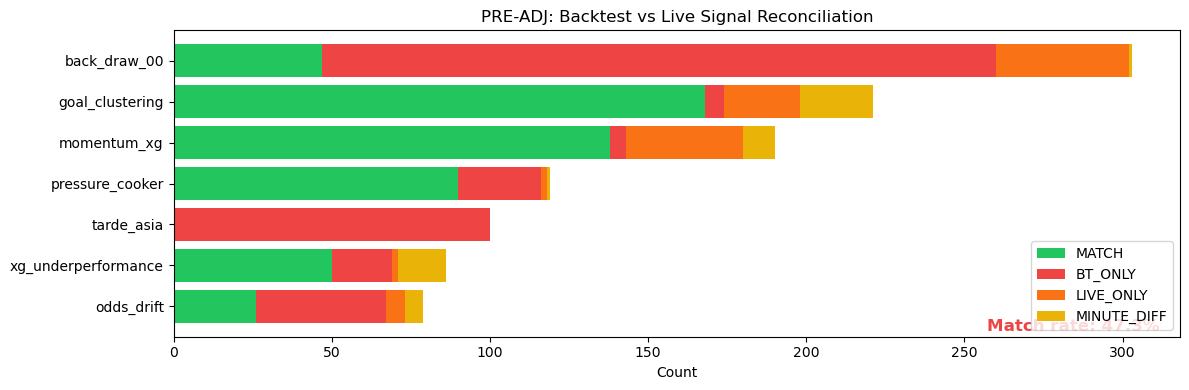

In [6]:
# ── Celda 6: Resumen visual (pre-adj) ──

if len(df_compare_raw) > 0:
    pivot = df_compare_raw.groupby(['strategy_family', 'status']).size().unstack(fill_value=0)
    for col in ['MATCH', 'BT_ONLY', 'LIVE_ONLY', 'MINUTE_DIFF']:
        if col not in pivot.columns: pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.5)))
    colors = {'MATCH': '#22c55e', 'BT_ONLY': '#ef4444', 'LIVE_ONLY': '#f97316', 'MINUTE_DIFF': '#eab308'}
    left = pd.Series(0, index=pivot.index)
    for st in ['MATCH', 'BT_ONLY', 'LIVE_ONLY', 'MINUTE_DIFF']:
        ax.barh(pivot.index, pivot[st], left=left, color=colors[st], label=st)
        left += pivot[st]
    ax.set_xlabel('Count'); ax.set_title('PRE-ADJ: Backtest vs Live Signal Reconciliation')
    ax.legend(loc='lower right')
    total_all = len(df_compare_raw)
    match_pct = 100 * (df_compare_raw['status'] == 'MATCH').sum() / total_all
    ax.text(0.98, 0.02, f'Match rate: {match_pct:.1f}%', transform=ax.transAxes,
            ha='right', fontsize=12, fontweight='bold',
            color='#22c55e' if match_pct >= 90 else '#ef4444')
    plt.tight_layout(); plt.show()
else:
    print('No comparison data.')

In [7]:
# ── Celda 7: Detalle de discrepancias (pre-adj) ──

df_disc_target = df_compare_raw  # Use pre-adj for diagnosis

if len(df_disc_target) > 0:
    df_disc = df_disc_target[df_disc_target['status'] != 'MATCH'].copy()
    
    if len(df_disc) == 0:
        print('No hay discrepancias! Backtest y Live estan 100% alineados.')
    else:
        print(f'=== {len(df_disc)} DISCREPANCIAS (pre-adj) ===')
        
        has_odds_bt = 'odds_bt' in df_disc.columns
        has_odds_live = 'odds_live' in df_disc.columns
        
        for status_type in ['BT_ONLY', 'LIVE_ONLY', 'MINUTE_DIFF']:
            subset = df_disc[df_disc['status'] == status_type]
            if len(subset) == 0:
                continue
            
            # Group by strategy
            by_strat = subset.groupby('strategy_family').size().sort_values(ascending=False)
            print(f'\n--- {status_type} ({len(subset)}) ---')
            print(f'  By strategy: {dict(by_strat)}')
            
            # Show first 10 examples per type
            shown = 0
            for _, row in subset.iterrows():
                if shown >= 10:
                    print(f'  ... and {len(subset) - 10} more')
                    break
                mid = row['match_id'][:50]
                strat = row['strategy_family']
                if status_type == 'BT_ONLY':
                    odds_s = f' odds={row["odds_bt"]:.2f}' if has_odds_bt and pd.notna(row.get('odds_bt')) else ''
                    print(f'  {mid} | {strat} | BT min={row["minuto_bt"]}{odds_s}')
                elif status_type == 'LIVE_ONLY':
                    odds_s = f' odds={row["odds_live"]:.2f}' if has_odds_live and pd.notna(row.get('odds_live')) else ''
                    print(f'  {mid} | {strat} | Live min={row["minuto_live"]}{odds_s}')
                else:
                    delta = abs(row['minuto_bt'] - row['minuto_live'])
                    print(f'  {mid} | {strat} | BT={row["minuto_bt"]} Live={row["minuto_live"]} D={delta:.0f}')
                shown += 1
else:
    print('No comparison data available.')

=== 579 DISCREPANCIAS (pre-adj) ===

--- BT_ONLY (410) ---
  By strategy: {'back_draw_00': np.int64(213), 'tarde_asia': np.int64(100), 'odds_drift': np.int64(41), 'pressure_cooker': np.int64(26), 'xg_underperformance': np.int64(19), 'goal_clustering': np.int64(6), 'momentum_xg': np.int64(5)}
  ac-milán-como-apuestas-35274228 | odds_drift | BT min=43.0 odds=1.66
  ac-ospitaletto-aurora-pro-patria-1919-apuestas-353 | back_draw_00 | BT min=32.0 odds=3.10
  aguilas-doradas-internacional-de-bogotá-apues | back_draw_00 | BT min=32.0 odds=2.60
  airdrieonians-raith-apuestas-35292497 | back_draw_00 | BT min=33.0 odds=2.82
  ajax-nec-nijmegen-apuestas-35243144 | back_draw_00 | BT min=32.0 odds=3.40
  ajax-nec-nijmegen-apuestas-35243144 | tarde_asia | BT min=0.0 odds=1.49
  al-ahli-al-ahli-uae-apuestas-35269087 | odds_drift | BT min=22.0 odds=2.80
  al-ahli-al-ahli-uae-apuestas-35269087 | tarde_asia | BT min=0.0 odds=1.68
  al-ahli-qat-sepahan-apuestas-35281006 | tarde_asia | BT min=6.0 odds=2.3

In [8]:
# ── Celda 8: Deep dive individual ──
# Cambia MATCH_ID para inspeccionar un partido concreto

MATCH_ID = ''  # <- Pegar aqui un match_id de las discrepancias

if MATCH_ID:
    print(f'=== Deep dive: {MATCH_ID} ===')
    print()
    
    # Backtest bets for this match
    bt_match = df_bt[df_bt['match_id'] == MATCH_ID]
    print(f'Backtest bets ({len(bt_match)}):')
    if len(bt_match) > 0:
        display(bt_match[['strategy_family', 'minuto_bt', 'odds_bt', 'won_bt', 'pl_bt']])
    else:
        print('  (ninguna)')
    print()
    
    # Live simulation for this match
    live_match = df_live[df_live['match_id'] == MATCH_ID] if len(df_live) > 0 else pd.DataFrame()
    print(f'Live signals fired ({len(live_match)}):')
    if len(live_match) > 0:
        display(live_match[['strategy_family', 'minuto_live', 'odds_live', 'strategy_key']])
    else:
        print('  (ninguna)')
    print()
    
    # Detailed row-by-row timeline for this match
    csv_path = DATA_DIR / f'partido_{MATCH_ID}.csv'
    if csv_path.exists():
        print('--- Timeline fila a fila ---')
        all_rows = _read_csv_rows_raw(csv_path)
        
        _orig_lg = csv_reader.load_games
        _orig_rp = csv_reader._resolve_csv_path
        _orig_rr = csv_reader._read_csv_rows
        _orig_op = builtins.open
        
        prev_sigs = set()
        timeline = []
        
        csv_path_obj = _Path(csv_path)  # Path object!
        
        try:
            csv_reader.load_games = lambda: [{'match_id': MATCH_ID, 'name': MATCH_ID, 'status': 'live', 'url': ''}]
            csv_reader._resolve_csv_path = lambda mid, _p=csv_path_obj: _p
            
            def _po(file, *a, **kw):
                if 'placed_bets' in str(file):
                    raise FileNotFoundError('patched')
                return _orig_op(file, *a, **kw)
            builtins.open = _po
            
            for i in range(len(all_rows)):
                partial = all_rows[:i + 1]
                row = all_rows[i]
                minute = row.get('minuto', '?')
                
                csv_reader._read_csv_rows = lambda path, _pr=partial: _pr
                
                try:
                    res = csv_reader.detect_betting_signals(VERSIONS)
                    curr_sigs = {s['strategy'] for s in res.get('signals', [])}
                except:
                    curr_sigs = set()
                
                appeared = curr_sigs - prev_sigs
                disappeared = prev_sigs - curr_sigs
                
                if appeared or disappeared:
                    evt = f'Row {i:3d} min={str(minute):>4s}'
                    if appeared:
                        evt += f'  ON: {", ".join(sorted(appeared))}'
                    if disappeared:
                        evt += f'  OFF: {", ".join(sorted(disappeared))}'
                    timeline.append(evt)
                
                prev_sigs = curr_sigs
        finally:
            csv_reader.load_games = _orig_lg
            csv_reader._resolve_csv_path = _orig_rp
            csv_reader._read_csv_rows = _orig_rr
            builtins.open = _orig_op
        
        if timeline:
            for line in timeline:
                print(line)
        else:
            print('No signal transitions detected in this match.')
    else:
        print(f'CSV not found: {csv_path}')
else:
    print('Establece MATCH_ID para inspeccionar un partido.')
    if 'df_compare' in dir():
        disc = df_compare[df_compare['status'] != 'MATCH']
        if len(disc) > 0:
            print('\nMatch IDs con discrepancias:')
            for mid in disc['match_id'].unique()[:20]:
                print(f'  {mid}')

Establece MATCH_ID para inspeccionar un partido.

Match IDs con discrepancias:
  ac-milán-como-apuestas-35274228
  ac-milán-parma-apuestas-35245355
  ac-ospitaletto-aurora-pro-patria-1919-apuestas-353
  accrington-barnet-apuestas-35292806
  agf-viborg-apuestas-35271662
  aguilas-doradas-internacional-de-bogotá-apues
  airdrieonians-raith-apuestas-35292497
  ajax-nec-nijmegen-apuestas-35243144
  al-ahli-al-najma-club-apuestas-35261533
  al-ahli-qat-sepahan-apuestas-35281006
  al-ahly-cairo-el-gounah-apuestas-35260500
  al-ettifaq-al-fateh-ksa-apuestas-35268319
  al-fateh-ksa-al-akhdoud-apuestas-35290188
  al-fateh-ksa-dhamk-apuestas-35302076
  al-feiha-al-nassr-apuestas-35306045
  al-gharafa-tractor-sazi-fc-apuestas-35277632
  al-hazm-ksa-al-ittihad-apuestas-35294101
  al-hilal-al-ittihad-apuestas-35264079
  al-hilal-al-wahda-abu-dhabi-apuestas-35269089
  al-ittihad-egy-ghazl-el-mahallah-apuestas-35309132


## Celda 9: Paper Bets vs BT/Live

Compara las apuestas reales del paper trading (`placed_bets.csv`) contra lo que BT predecía y lo que Live simulado detectó.
Para cada apuesta real muestra si BT la tenía (MATCH), si es extra (LIVE_ONLY), o si BT la esperaba pero no se colocó (BT_ONLY).

In [ ]:
# ── Celda 9: Paper Bets reales vs BT y Live simulado ──
import csv as _csv9
from pathlib import Path as _P9
from urllib.parse import unquote as _unq9

PLACED_BETS_CSV = ROOT / 'betfair_scraper' / 'placed_bets.csv'

# ── 1. Leer placed_bets.csv ──
paper_bets = []
if PLACED_BETS_CSV.exists():
    with open(PLACED_BETS_CSV, 'r', encoding='utf-8') as f:
        for row in _csv9.DictReader(f):
            paper_bets.append(row)

if not paper_bets:
    print('No hay apuestas en placed_bets.csv todavía.')
else:
    # ── 2. Normalizar paper bets ──
    PAPER_STRAT_TO_FAMILY = {
        'back_draw_00_v1': 'back_draw_00', 'back_draw_00_v15': 'back_draw_00',
        'back_draw_00_v2': 'back_draw_00', 'back_draw_00_v2r': 'back_draw_00',
        'back_draw_00_v3': 'back_draw_00', 'back_draw_00_v4': 'back_draw_00',
        'xg_underperformance_base': 'xg_underperformance',
        'xg_underperformance_v2': 'xg_underperformance',
        'xg_underperformance_v3': 'xg_underperformance',
        'odds_drift_contrarian_v1': 'odds_drift', 'odds_drift_contrarian_v2': 'odds_drift',
        'odds_drift_contrarian_v3': 'odds_drift', 'odds_drift_contrarian_v4': 'odds_drift',
        'odds_drift_contrarian_v5': 'odds_drift', 'odds_drift_contrarian_v6': 'odds_drift',
        'goal_clustering_v2': 'goal_clustering', 'goal_clustering_v3': 'goal_clustering',
        'goal_clustering_v4': 'goal_clustering',
        'pressure_cooker_v1': 'pressure_cooker', 'pressure_cooker_v2': 'pressure_cooker',
        'momentum_xg_v1': 'momentum_xg', 'momentum_xg_v2': 'momentum_xg',
        'tarde_asia_v1': 'tarde_asia',
        'lay_over15_v1': 'lay_over15',
        'lay_draw_asym': 'lay_draw_asym',
        'lay_over25_def': 'lay_over25_def',
        'back_sot_dom': 'back_sot_dom',
        'back_over15_early': 'back_over15_early',
        'lay_false_fav': 'lay_false_fav',
    }

    def _paper_family(strat_key):
        if strat_key in PAPER_STRAT_TO_FAMILY:
            return PAPER_STRAT_TO_FAMILY[strat_key]
        return _normalize_strategy(strat_key)

    paper_records = []
    for b in paper_bets:
        try:
            odds = float(b.get('back_odds', 0))
        except (ValueError, TypeError):
            odds = None
        try:
            minute = float(b.get('minute', 0))
        except (ValueError, TypeError):
            minute = None
        try:
            pl = float(b.get('pl', 0)) if b.get('pl') else None
        except (ValueError, TypeError):
            pl = None

        paper_records.append({
            'match_id': b.get('match_id', ''),
            'match_name': b.get('match_name', ''),
            'strategy_family': _paper_family(b.get('strategy', '')),
            'strategy_raw': b.get('strategy', ''),
            'minute_paper': minute,
            'odds_paper': odds,
            'status': b.get('status', ''),
            'result': b.get('result', ''),
            'pl': pl,
            'score': b.get('score', ''),
        })

    df_paper = pd.DataFrame(paper_records)
    print(f'Paper bets: {len(df_paper)}')
    print(f'  Por estado: {dict(df_paper["status"].value_counts())}')
    print(f'  Por estrategia: {dict(df_paper["strategy_family"].value_counts())}')
    if df_paper['pl'].notna().any():
        print(f'  P/L total: {df_paper["pl"].sum():.2f}€')

    # ── 3. Cruzar paper vs BT ──
    print(f'\n{"="*60}')
    print('PAPER BETS vs BACKTEST')
    print(f'{"="*60}')

    df_paper_bt = pd.merge(
        df_paper[['match_id', 'strategy_family', 'minute_paper', 'odds_paper', 'status', 'result', 'pl', 'match_name', 'score']],
        df_bt_raw[['match_id', 'strategy_family', 'minuto_bt', 'odds_bt', 'won_bt', 'pl_bt']],
        on=['match_id', 'strategy_family'], how='left', indicator=True
    )
    df_paper_bt['in_bt'] = df_paper_bt['_merge'] == 'both'

    n_in_bt = df_paper_bt['in_bt'].sum()
    n_not_bt = (~df_paper_bt['in_bt']).sum()
    print(f'\n  En BT: {n_in_bt}/{len(df_paper_bt)} ({100*n_in_bt/len(df_paper_bt):.0f}%)')
    print(f'  No en BT (extra live): {n_not_bt}/{len(df_paper_bt)} ({100*n_not_bt/len(df_paper_bt):.0f}%)')

    # ── 4. Cruzar paper vs Live simulado ──
    print(f'\n{"="*60}')
    print('PAPER BETS vs LIVE SIMULADO')
    print(f'{"="*60}')

    if len(df_live) > 0:
        df_paper_live = pd.merge(
            df_paper[['match_id', 'strategy_family', 'minute_paper', 'odds_paper', 'status', 'result', 'pl', 'match_name', 'score']],
            df_live[['match_id', 'strategy_family', 'minuto_live', 'odds_live']],
            on=['match_id', 'strategy_family'], how='left', indicator=True
        )
        df_paper_live['in_live_sim'] = df_paper_live['_merge'] == 'both'
        n_in_live = df_paper_live['in_live_sim'].sum()
        n_not_live = (~df_paper_live['in_live_sim']).sum()
        print(f'\n  En Live sim: {n_in_live}/{len(df_paper_live)} ({100*n_in_live/len(df_paper_live):.0f}%)')
        print(f'  No en Live sim: {n_not_live}/{len(df_paper_live)} ({100*n_not_live/len(df_paper_live):.0f}%)')
    else:
        print('  (sin datos live simulado)')

    # ── 5. Tabla detallada por apuesta ──
    print(f'\n{"="*60}')
    print('DETALLE POR APUESTA')
    print(f'{"="*60}\n')

    for _, row in df_paper.iterrows():
        mid = row['match_id']
        fam = row['strategy_family']
        name = row['match_name']

        # Buscar en BT
        bt_match = df_bt_raw[(df_bt_raw['match_id'] == mid) & (df_bt_raw['strategy_family'] == fam)]
        in_bt = len(bt_match) > 0
        bt_info = ''
        if in_bt:
            bt_r = bt_match.iloc[0]
            bt_info = f'BT min={bt_r["minuto_bt"]} odds={bt_r["odds_bt"]}'
            if pd.notna(bt_r.get('won_bt')):
                bt_info += f' {"W" if bt_r["won_bt"] else "L"}'

        # Buscar en Live sim
        if len(df_live) > 0:
            live_match = df_live[(df_live['match_id'] == mid) & (df_live['strategy_family'] == fam)]
            in_live = len(live_match) > 0
            live_info = ''
            if in_live:
                lv_r = live_match.iloc[0]
                live_info = f'Live min={lv_r["minuto_live"]} odds={lv_r["odds_live"]}'
        else:
            in_live = False
            live_info = ''

        # Clasificar
        if in_bt and in_live:
            tag = 'BT+LIVE'
        elif in_bt:
            tag = 'BT_ONLY'
        elif in_live:
            tag = 'LIVE_ONLY'
        else:
            tag = 'PAPER_ONLY'  # ni BT ni live sim lo tenían

        status_str = row['status']
        pl_str = f'{row["pl"]:+.2f}€' if pd.notna(row['pl']) else 'pending'
        score_str = f' ({row["score"]})' if row['score'] else ''

        print(f'  [{tag:10s}] {name}{score_str}')
        print(f'             {fam} | Paper: min={row["minute_paper"]} odds={row["odds_paper"]} → {status_str} {pl_str}')
        if bt_info:
            print(f'             {bt_info}')
        if live_info:
            print(f'             {live_info}')
        print()

    # ── 6. BT_ONLY: qué predecía BT que no se colocó ──
    paper_keys = set(zip(df_paper['match_id'], df_paper['strategy_family']))
    bt_not_placed = df_bt_raw[~df_bt_raw.apply(lambda r: (r['match_id'], r['strategy_family']) in paper_keys, axis=1)]

    # Solo mostrar partidos recientes (si hay timestamp en placed_bets)
    if len(paper_bets) > 0 and paper_bets[0].get('timestamp_utc'):
        first_paper_ts = min(b.get('timestamp_utc', '') for b in paper_bets if b.get('timestamp_utc'))
        print(f'\n{"="*60}')
        print(f'BT esperaba pero NO se colocó (total: {len(bt_not_placed)} — normal, son partidos históricos)')
        print(f'{"="*60}')
        print(f'  (Solo se muestran partidos desde el inicio del paper trading: {first_paper_ts[:10]})')
    else:
        print(f'\nBT_ONLY no colocadas: {len(bt_not_placed)} (partidos históricos, esperado)')